In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
r_s = 1
L = 10
b = 2

x = -L / 2
y = b

r = np.hypot(x, y)
phi = np.arctan2(y, x)
dr = x / r
dphi = -y / r**2

x, y, r, phi, dr, dphi

(-5.0,
 2,
 np.float64(5.385164807134504),
 np.float64(2.761086276477428),
 np.float64(-0.9284766908852594),
 np.float64(-0.06896551724137932))

In [3]:
dl = 1e-4

r_list = [r]
phi_list = [phi]
for _ in tqdm(range(int(1e5))):
    r += dr * dl
    phi += dphi * dl
    dr += (r - 1.5 * r_s) * dphi ** 2 * dl
    dphi += (-2 / r * dr * dphi) * dl
    if r < r_s:
        continue
    r_list.append(r)
    phi_list.append(phi)

r_list = np.array(r_list)
phi_list = np.array(phi_list)

  0%|                                                                                                             | 0/100000 [00:00<?, ?it/s]/tmp/ipykernel_3614/131590794.py:8: RuntimeWarning: overflow encountered in scalar multiply
  dr += (r - 1.5 * r_s) * dphi ** 2 * dl
/tmp/ipykernel_3614/131590794.py:9: RuntimeWarning: invalid value encountered in scalar multiply
  dphi += (-2 / r * dr * dphi) * dl
100%|███████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:00<00:00, 1595314.06it/s]


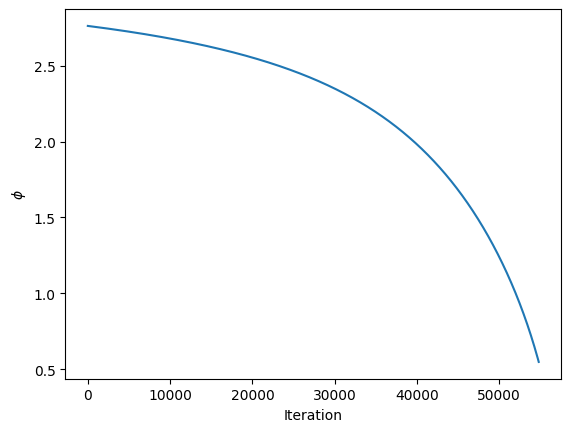

In [4]:
fig, ax = plt.subplots()

ax.plot(phi_list)
ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\phi$')

plt.show()

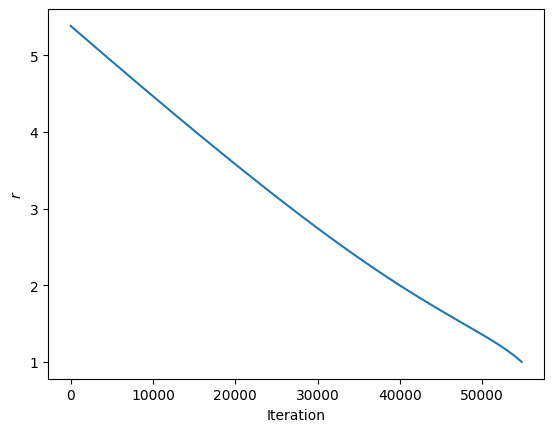

In [5]:
fig, ax = plt.subplots()

ax.plot(r_list)
ax.set_xlabel('Iteration')
ax.set_ylabel(r'$r$')

plt.show()

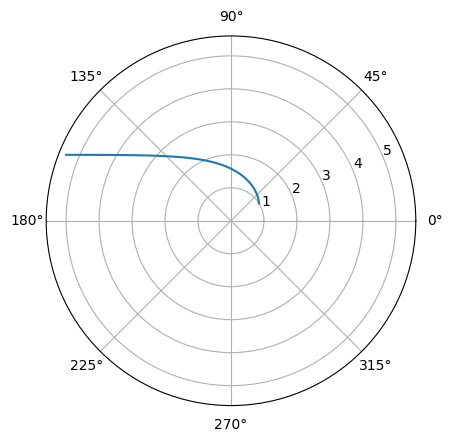

In [6]:
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

ax.plot(phi_list, r_list)

plt.show()